In [1]:
# montar drive
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# cargar archivo de excel

# -----------------------------
# Reading the database
# -----------------------------
file_path = '/content/drive/My Drive/Curso Mineria de Datos 2024/Semana 5 - Aprendizaje Supervisado - SVM, Arboles de decisión/county_level_election.csv'

# Load the data
data = pd.read_csv(file_path)

In [4]:
data.head()

,state,fipscode,county,population,hispanic,minority,female,unemployed,income,nodegree,bachelor,inactivity,obesity,density,cancer,votergap,trump,clinton
0,Colorado,8117,Summit County,27239,15.173,4.918,45.996,2.5,68352,5.4,48.1,8.1,13.1,46.0,46.2,-27.632,31.530,59.162
1,Colorado,8037,Eagle County,53653,30.040,5.169,47.231,3.1,76661,10.1,47.3,9.4,11.8,31.0,47.1,-19.897,36.058,55.955
2,Idaho,16067,Minidoka County,19226,34.070,5.611,49.318,3.7,46332,24.1,11.8,18.3,34.2,80.0,61.8,54.148,71.135,16.987
3,Colorado,8113,San Miguel County,7558,10.154,4.747,46.808,3.7,59603,4.7,54.4,12.4,16.7,5.7,62.6,-44.769,23.892,68.662
4,Utah,49051,Wasatch County,21600,13.244,4.125,48.812,3.4,65207,9.5,34.4,13.9,23.0,257.8,68.3,25.357,50.471,25.114


In [5]:
# EDA: Advanced Analysis
# Basic dataset info
print("Dataset Info:")
data.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066 entries, 0 to 3065
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state       3066 non-null   object 
 1   fipscode    3066 non-null   int64  
 2   county      3066 non-null   object 
 3   population  3066 non-null   int64  
 4   hispanic    3066 non-null   float64
 5   minority    3066 non-null   float64
 6   female      3066 non-null   float64
 7   unemployed  3066 non-null   float64
 8   income      3066 non-null   int64  
 9   nodegree    3066 non-null   float64
 10  bachelor    3066 non-null   float64
 11  inactivity  3066 non-null   float64
 12  obesity     3066 non-null   float64
 13  density     3066 non-null   float64
 14  cancer      3066 non-null   float64
 15  votergap    3066 non-null   float64
 16  trump       3066 non-null   float64
 17  clinton     3066 non-null   float64
dtypes: float64(13), int64(3), object(2)
memory usage: 431.

In [6]:

# Check for missing values
missing_data = data.isnull().sum()
print("\nMissing Data Summary:")
print(missing_data[missing_data > 0])




Missing Data Summary:
Series([], dtype: int64)


In [12]:
# Pairplot for relationships (only numeric features for now)
sns.pairplot(data.select_dtypes(include=[np.number]), diag_kind='kde')
plt.show()



Output hidden; open in https://colab.research.google.com to view.

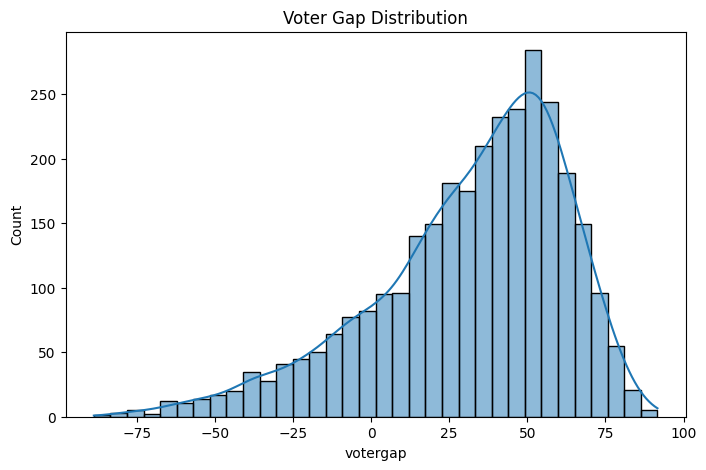

In [7]:
# Distribution of target variable
plt.figure(figsize=(8, 5))
sns.histplot(data['votergap'], kde=True)
plt.title('Voter Gap Distribution')
plt.show()



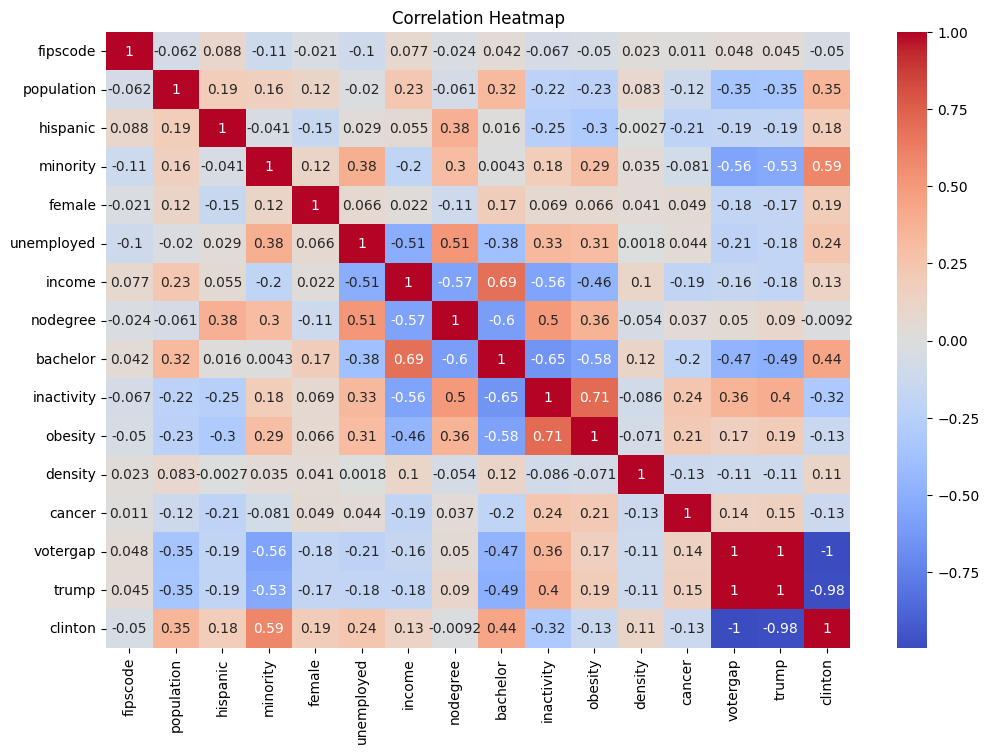

In [8]:
# Analyze correlations between numerical variables
plt.figure(figsize=(12, 8))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


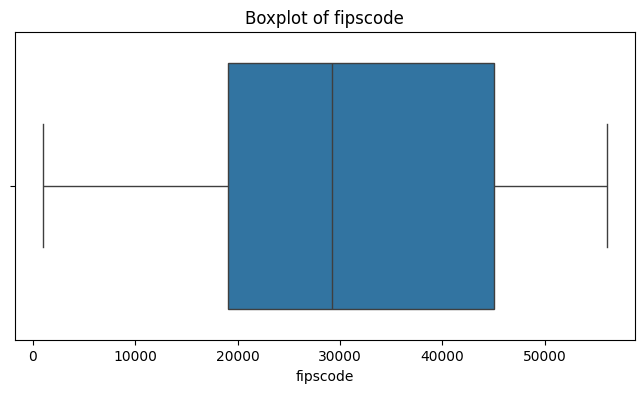

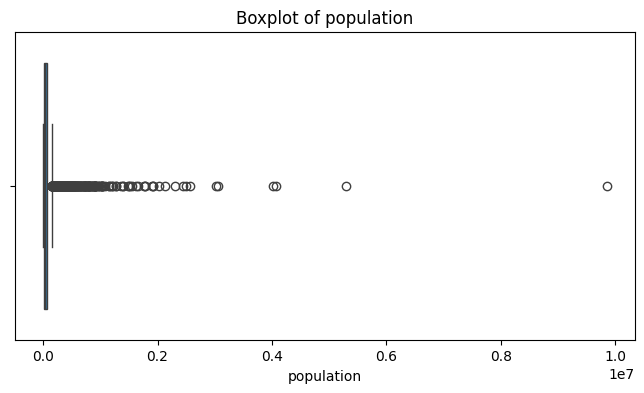

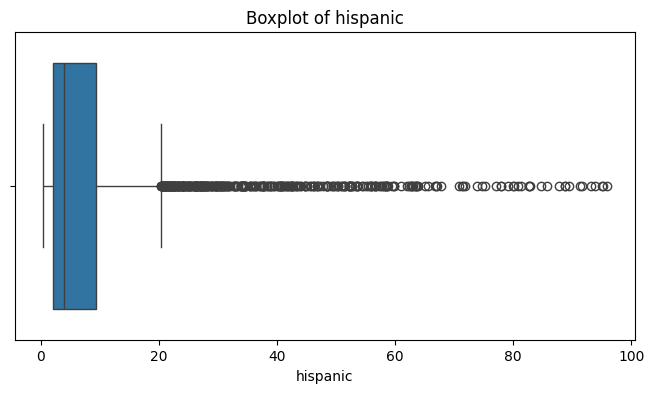

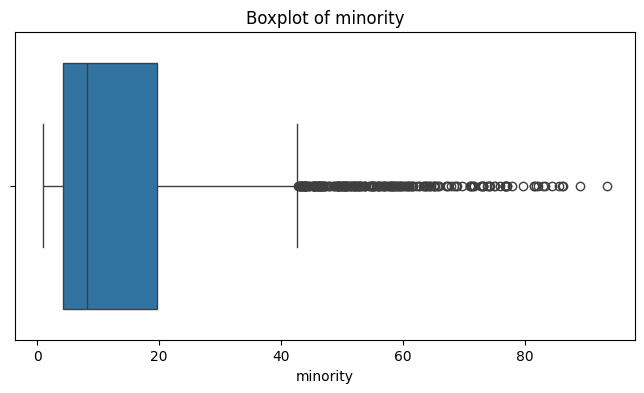

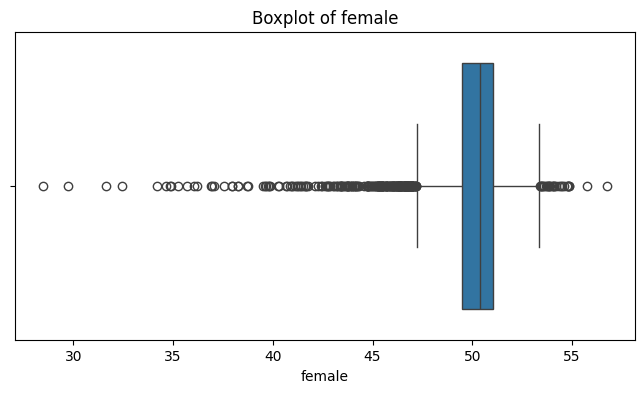

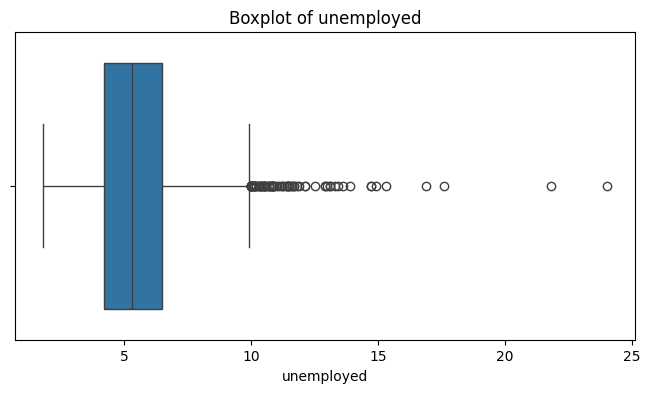

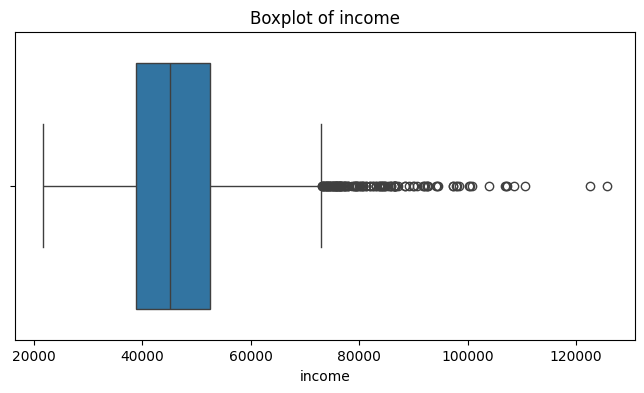

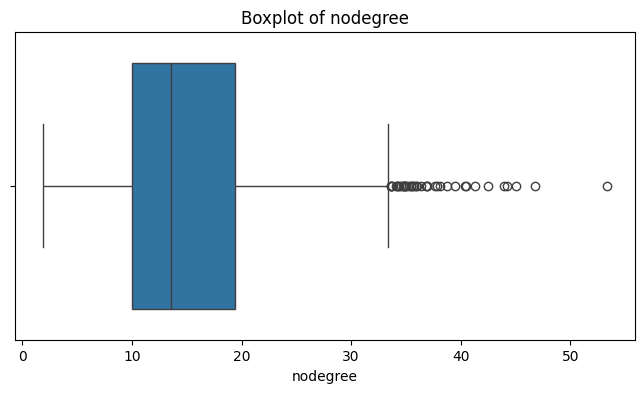

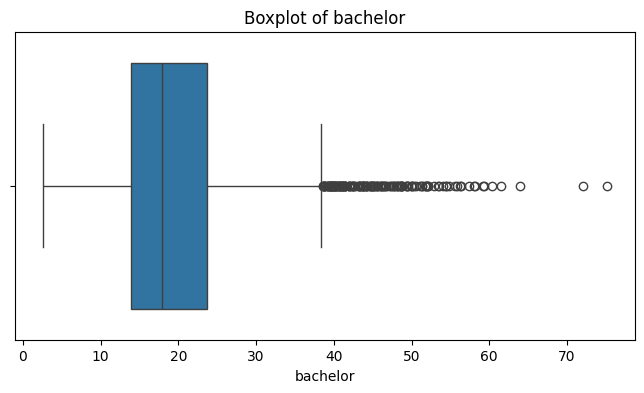

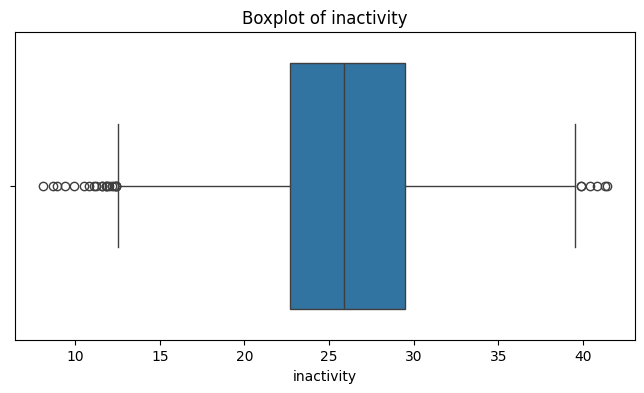

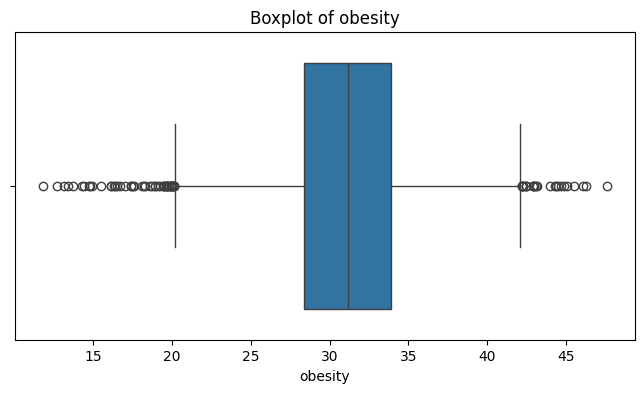

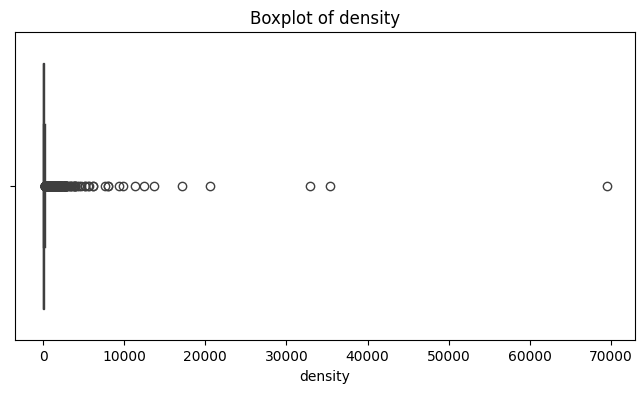

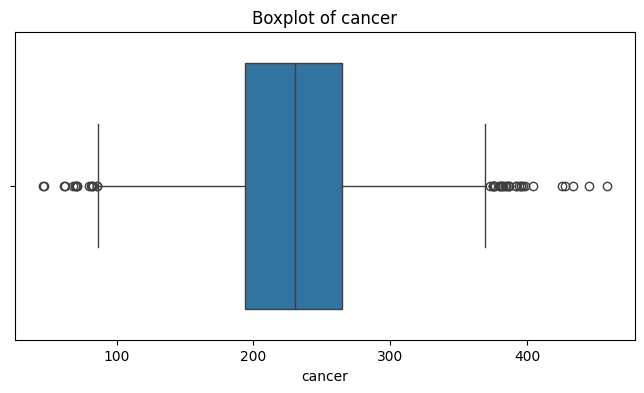

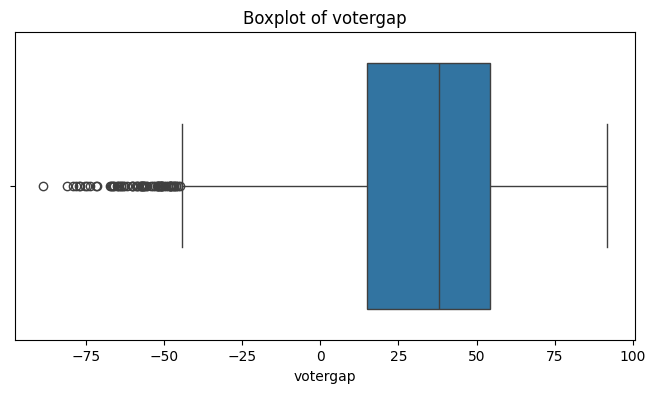

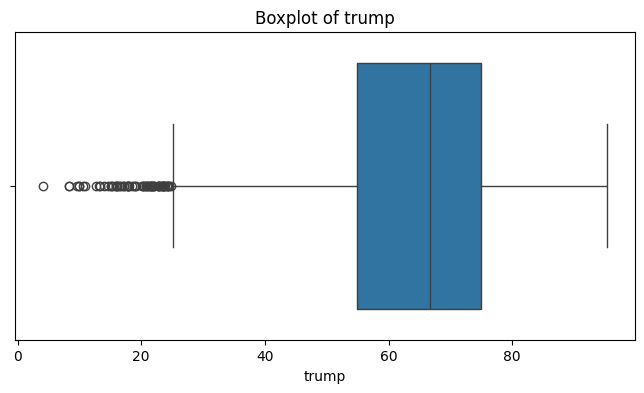

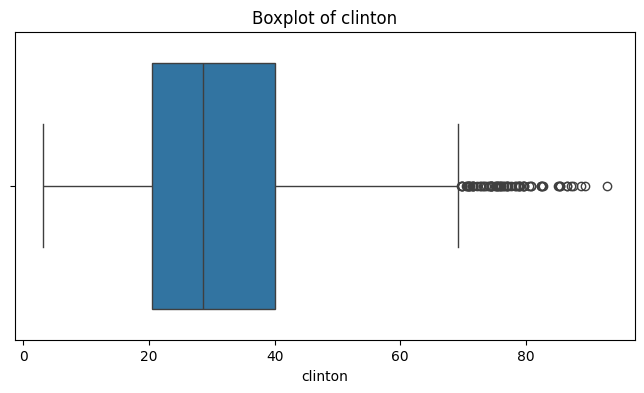

In [9]:

# Create boxplots for each numerical variable individually
numeric_columns = data.select_dtypes(include=[np.number]).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


In [10]:
# unique values of categorical features
categorical_columns = data.select_dtypes(include=['object']).columns

for column in categorical_columns:
    print(f"Unique values in {column}:")
    print(data[column].unique())
    print(len(data[column].unique()))
    print()

Unique values in state:
['Colorado' 'Idaho' 'Utah' 'Virginia' 'Georgia' 'California' 'Kansas'
 'Texas' 'Arizona' 'Wyoming' 'South Dakota' 'Washington' 'Illinois'
 'Minnesota' 'New Mexico' 'Montana' 'Nevada' 'Vermont' 'Indiana'
 'North Carolina' 'Maryland' 'Iowa' 'Mississippi' 'Tennessee' 'Missouri'
 'Oklahoma' 'Nebraska' 'North Dakota' 'Ohio' 'Oregon' 'Florida'
 'West Virginia' 'Pennsylvania' 'New Jersey' 'Wisconsin' 'Michigan'
 'Alabama' 'Louisiana' 'Kentucky' 'Arkansas' 'New York' 'South Carolina'
 'Connecticut' 'Massachusetts' 'Hawaii' 'New Hampshire'
 'District of Columbia' 'Delaware' 'Rhode Island' 'Maine']
50

Unique values in county:
['Summit County' 'Eagle County' 'Minidoka County' ... 'Hettinger County'
 'Eureka County' 'Wyandotte County']
1823



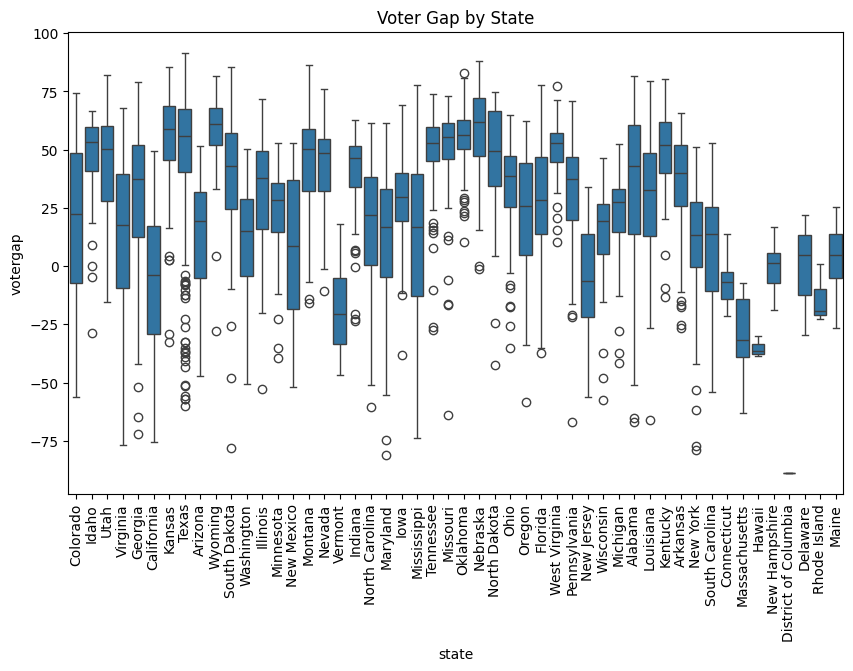

In [11]:

# Analyzing categorical features' impact on 'votergap'
plt.figure(figsize=(10, 6))
sns.boxplot(x='state', y='votergap', data=data)
plt.xticks(rotation=90)
plt.title('Voter Gap by State')
plt.show()

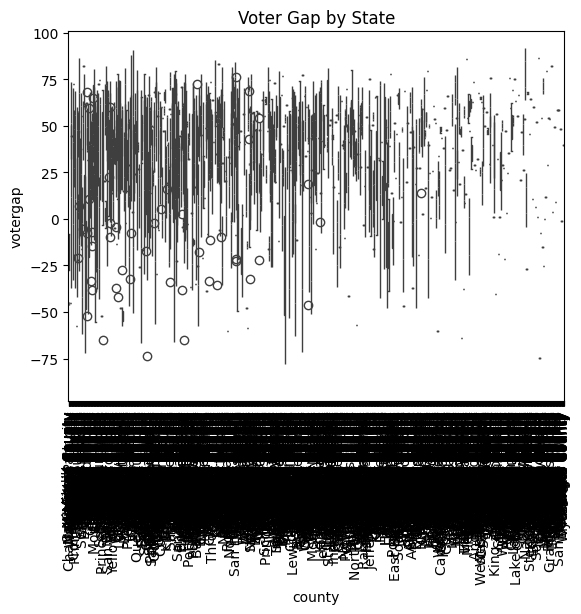

In [23]:
# Analyzing categorical features' impact on 'votergap'

sns.boxplot(x='county', y='votergap', data=data)
plt.xticks(rotation=90)
plt.title('Voter Gap by State')
plt.show()

In [12]:
from sklearn.preprocessing import PolynomialFeatures

# Feature Engineering: Creating new features
data['income_per_capita'] = data['income'] / data['population']
data['unemployed_per_capita'] = data['unemployed'] * data['population'] / 100

# Creating polynomial features (interaction terms) for numerical data
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(data[['population', 'income', 'unemployed']])

# Incorporating new polynomial features into the dataset
poly_df = pd.DataFrame(poly_features, columns=[f'poly_{i}' for i in range(poly_features.shape[1])])
data = pd.concat([data, poly_df], axis=1)

In [13]:
# Step 1: Split the data
X = data.drop(['votergap', 'county','fipscode'], axis=1) # Dado que son tantas variables categoricas vamos a eliminarlas.
y = data['votergap']

In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [15]:


# Step 2: Preprocessing for numerical and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns



In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer

# Transformer to apply Yeo-Johnson transformation to numerical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson'))
])

# Categorical transformer (simple one-hot encoding)
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop ='first', sparse_output= False)

# Full preprocessor for both numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [32]:
# Pipeline para Linear Regression con preprocesamiento, remoción de outliers y selección de variables
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=10)),
    ('model', LinearRegression())
])

# Entrenamiento y evaluación para Linear Regression
pipeline_lr.fit(X_train, y_train)
print("Linear Regression Test R2:", pipeline_lr.score(X_test, y_test))


Linear Regression Test R2: 0.956147956087478


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [33]:
from sklearn.model_selection import RandomizedSearchCV

# Pipeline para SVR
pipeline_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=10)),
    ('model', SVR())
])

# GridSearch para SVR
param_grid_svr = {'model__C': [0.1, 1, 10],
                  'model__kernel': ['linear', 'rbf']}

grid_search_svr = RandomizedSearchCV(pipeline_svr, param_grid_svr, cv=5)
grid_search_svr.fit(X_train, y_train)
print("SVR Best Params:", grid_search_svr.best_params_)
print("SVR R2:", grid_search_svr.score(X_test, y_test))



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SVR Best Params: {'model__kernel': 'rbf', 'model__C': 10}
SVR R2: 0.9970088051974487


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [34]:
# Pipeline para Lasso
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

# GridSearch para Lasso
param_grid_lasso = {'model__alpha': [0.01, 0.1, 1, 10]}
grid_search_lasso = RandomizedSearchCV(pipeline_lasso, param_grid_lasso, cv=5)
grid_search_lasso.fit(X_train, y_train)
print("Lasso Best Params:", grid_search_lasso.best_params_)
print("Lasso R2:", grid_search_lasso.score(X_test, y_test))


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.470e+03, tolerance: 1.822e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.336e+03, tolerance: 1.842e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordi

Lasso Best Params: {'model__alpha': 0.01}
Lasso R2: 0.9609331174674068


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.978e+03, tolerance: 2.328e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [35]:
# Pipeline para Ridge
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# GridSearch para Ridge
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1, 10]}
grid_search_ridge = RandomizedSearchCV(pipeline_ridge, param_grid_ridge, cv=5)
grid_search_ridge.fit(X_train, y_train)
print("Ridge Best Params:", grid_search_ridge.best_params_)
print("Ridge R2:", grid_search_ridge.score(X_test, y_test))


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Best Params: {'model__alpha': 1}
Ridge R2: 0.9611823003170753


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [37]:
# Preprocesamiento solo para las variables categóricas (One-Hot Encoding)
categorical_transformer_tree = OneHotEncoder(handle_unknown='ignore')

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer_tree, categorical_features)
    ], remainder='passthrough')  # Passthrough permite que las variables numéricas se mantengan sin cambios


In [38]:
# Pipeline para Árbol de Decisión (con One-Hot Encoding para variables categóricas)
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeRegressor())
])

# GridSearch para Árbol de Decisión
param_grid_tree = {'model__max_depth': [5, 10, 15]}

grid_search_tree = RandomizedSearchCV(pipeline_tree, param_grid_tree, cv=5)

grid_search_tree.fit(X_train, y_train)
print("Decision Tree Best Params:", grid_search_tree.best_params_)
print("Decision Tree R2:", grid_search_tree.score(X_test, y_test))



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Decision Tree Best Params: {'model__max_depth': 15}
Decision Tree R2: 0.9981549871735037


In [40]:
# Pipeline para Random Forest (con One-Hot Encoding para variables categóricas)
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestRegressor())
])

# GridSearch para Random Forest
param_grid_rf = {'model__n_estimators': [100, 200],
                 'model__max_depth': [5, 10]}

grid_search_rf = RandomizedSearchCV(pipeline_rf, param_grid_rf, cv=5)
grid_search_rf.fit(X_train, y_train)
print("Random Forest Best Params:", grid_search_rf.best_params_)
print("Random Forest R2:", grid_search_rf.score(X_test, y_test))


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random Forest Best Params: {'model__n_estimators': 100, 'model__max_depth': 10}
Random Forest R2: 0.999421917602651


In [ ]:
# Pipeline para Gradient Boosting (con One-Hot Encoding para variables categóricas)
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', GradientBoostingRegressor())
])

# GridSearch para Gradient Boosting
param_grid_gb = {'model__n_estimators': [100, 200],
                 'model__learning_rate': [0.01, 0.1, 0.2]}
grid_search_gb = RandomizedSearchCV(pipeline_gb, param_grid_gb, cv=5)
grid_search_gb.fit(X_train, y_train)
print("Gradient Boosting Best Params:", grid_search_gb.best_params_)
print("Gradient Boosting R2:", grid_search_gb.score(X_test, y_test))



In [ ]:
# Pipeline para Bagging (con One-Hot Encoding para variables categóricas)
pipeline_bagging = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', BaggingRegressor(base_estimator=DecisionTreeRegressor()))
])

# GridSearch para Bagging
param_grid_bagging = {'model__n_estimators': [50, 100]}
grid_search_bagging = RandomizedSearchCV(pipeline_bagging, param_grid_bagging, cv=5)
grid_search_bagging.fit(X_train, y_train)
print("Bagging Best Params:", grid_search_bagging.best_params_)
print("Bagging R2:", grid_search_bagging.score(X_test, y_test))

